# Step 4: Constrained Portfolio Construction & Final Evaluation

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr

from pypfopt import EfficientFrontier, expected_returns, risk_models
from pypfopt.objective_functions import L2_reg

warnings.filterwarnings('ignore')

DATA_PROC = 'data/processed'
DATA_RAW  = 'data/raw'
os.makedirs('outputs', exist_ok=True)

VAL_END = pd.Timestamp('2023-12-31')

## 1. Load Signals and Price Data

In [ ]:
signals = pd.read_parquet(os.path.join(DATA_PROC, 'test_signals.parquet'))
signals['event_date'] = pd.to_datetime(signals['event_date'])
signals = signals.sort_values('event_date').reset_index(drop=True)

prices_long = pd.read_parquet(os.path.join(DATA_RAW, 'prices_daily.parquet'))
prices_long['date'] = pd.to_datetime(prices_long['date'])

prices = (
    prices_long[prices_long['date'] > VAL_END]
    .pivot(index='date', columns='ticker', values='close')
    .sort_index()
)

daily_rets = np.log(prices).diff().dropna()
trading_dates = daily_rets.index.tolist()

UNIVERSE = prices.columns.tolist()
print(f'Test period prices: {prices.shape}  ({prices.index[0].date()} – {prices.index[-1].date()})')
print(f'Test signals: {len(signals)} events')

import json
with open(os.path.join(DATA_RAW, 'sp500_sectors.json')) as f:
    TICKER_TO_SECTOR = json.load(f)
signals['sector'] = signals['ticker'].map(TICKER_TO_SECTOR).fillna('Unknown')
print(f'Sector coverage: {(signals["sector"] != "Unknown").mean():.1%} of test events')
print(f'Sector counts: {signals["sector"].value_counts().to_dict()}')

def cross_sectional_zscore(df: pd.DataFrame, signal_col: str,
                            group_col: str = None) -> pd.Series:
    group_cols = ['_month']
    if group_col is not None and group_col in df.columns:
        group_cols.append(group_col)
    d = df.copy()
    d['_month'] = d['event_date'].dt.to_period('M')
    grouped = d.groupby(group_cols)[signal_col]
    mu  = grouped.transform('mean')
    std = grouped.transform('std').replace(0, np.nan)
    return ((d[signal_col] - mu) / std).fillna(0.0)


for col in ['sentiment', 'pred_5d_b2', 'pred_20d_b2', 'pred_5d_tcmda', 'pred_20d_tcmda']:
    if col in signals.columns:
        signals[col + '_z']     = cross_sectional_zscore(signals, col)
        signals[col + '_zsect'] = cross_sectional_zscore(signals, col, group_col='sector')

new_cols = [c for c in signals.columns if c.endswith('_z') or c.endswith('_zsect')]
print(f'Added normalized signal columns: {new_cols}')

Test period prices: (251, 463)  (2024-01-02 – 2024-12-30)
Test signals: 918 events
Sector coverage: 100.0% of test events
Sector counts: {'Financials': 142, 'Industrials': 138, 'Information Technology': 128, 'Health Care': 110, 'Consumer Discretionary': 92, 'Consumer Staples': 69, 'Real Estate': 58, 'Utilities': 58, 'Materials': 47, 'Energy': 42, 'Communication Services': 34}
Added normalized signal columns: ['sentiment_z', 'sentiment_zsect', 'pred_5d_b2_z', 'pred_5d_b2_zsect', 'pred_20d_b2_z', 'pred_20d_b2_zsect', 'pred_5d_tcmda_z', 'pred_5d_tcmda_zsect', 'pred_20d_tcmda_z', 'pred_20d_tcmda_zsect']


## 2. Signal-to-Weight Mapping

In [ ]:
def score_to_longonly_weights(scores: dict, max_weight: float = 0.10,
                               top_n: int = 20) -> dict:
    if not scores:
        return {}
    items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    items = [(t, s) for t, s in items if s > 0][:top_n]
    if not items:
        return {}
    tickers, raw = zip(*items)
    raw = np.array(raw, dtype=float)
    raw = np.clip(raw, 0, None)
    total = raw.sum()
    if total == 0:
        return {}
    w = raw / total
    w = np.minimum(w, max_weight)
    w = w / w.sum()
    return dict(zip(tickers, w))


def quintile_weights(scores: dict, which: str = 'long',
                     quintile: float = 0.20, max_weight: float = 0.10) -> dict:
    if not scores or len(scores) < 5:
        return {}
    items = sorted(scores.items(), key=lambda x: x[1], reverse=(which == 'long'))
    cutoff = max(1, int(np.ceil(len(items) * quintile)))
    selected = items[:cutoff]
    if not selected:
        return {}
    w = 1.0 / len(selected)
    w = min(w, max_weight)
    return {t: w for t, _ in selected}


def long_short_quintile_weights(scores: dict, quintile: float = 0.20,
                                 max_weight: float = 0.10) -> dict:
    if not scores or len(scores) < 10:
        return {}
    long_w  = quintile_weights(scores, which='long',  quintile=quintile, max_weight=max_weight)
    short_w = quintile_weights(scores, which='short', quintile=quintile, max_weight=max_weight)
    combined = {t: w for t, w in long_w.items()}
    for t, w in short_w.items():
        combined[t] = combined.get(t, 0.0) - w    # short side negative
    return combined


def signal_to_mv_weights(scores: dict, cov_matrix: pd.DataFrame,
                          max_weight: float = 0.10, top_n: int = 20) -> dict:
    if not scores or len(scores) < 5:
        return score_to_longonly_weights(scores, max_weight, top_n)

    items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    items = [(t, s) for t, s in items if s > 0 and t in cov_matrix.columns][:top_n]
    if len(items) < 3:
        return score_to_longonly_weights(scores, max_weight, top_n)

    tickers = [t for t, _ in items]
    mu = pd.Series({t: s for t, s in items})
    S  = cov_matrix.loc[tickers, tickers]

    try:
        ef = EfficientFrontier(mu, S, weight_bounds=(0, max_weight))
        ef.add_objective(L2_reg, gamma=0.1)
        ef.max_sharpe(risk_free_rate=0.0)
        weights = ef.clean_weights()
        return {t: w for t, w in weights.items() if w > 1e-4}
    except Exception:
        return score_to_longonly_weights(scores, max_weight, top_n)

## 3. Weekly Backtest Engine

In [ ]:
HALF_SPREAD = 0.0005
IMPACT_COEF = 0.0010

def transaction_cost(prev_w: dict, new_w: dict) -> float:
    all_tickers = set(prev_w) | set(new_w)
    total_cost  = 0.0
    for t in all_tickers:
        delta = abs(new_w.get(t, 0.0) - prev_w.get(t, 0.0))
        if delta > 1e-6:
            cost_rate = HALF_SPREAD + IMPACT_COEF * np.sqrt(delta)
            total_cost += cost_rate * delta
    return total_cost


TRADING_DATE_INDEX = {d: i for i, d in enumerate(trading_dates)}
def next_trading_day_idx(d):
    if d in TRADING_DATE_INDEX:
        return TRADING_DATE_INDEX[d]
    for i, td in enumerate(trading_dates):
        if td >= d:
            return i
    return -1


def buffered_quintile_weights(scores: dict, prev_holdings: set,
                               n_enter: int = 15, n_exit: int = 30,
                               max_weight: float = 0.10) -> dict:
    if not scores:
        return {}
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    ranked_tickers = [t for t, _ in ranked]
    entry_set = set(ranked_tickers[:n_enter])
    exit_floor = set(ranked_tickers[:n_exit])
    retained = {t for t in prev_holdings if t in exit_floor}
    holdings = entry_set | retained
    if not holdings:
        holdings = entry_set
    if not holdings:
        return {}
    w = min(1.0 / len(holdings), max_weight)
    return {t: w for t in holdings}


def run_backtest(signal_col: str, strategy: str = 'quintile',
                 max_weight: float = 0.10, top_n: int = 20, signal_ttl: int = 45,
                 form_filter=None, flip_sign: bool = False,
                 n_enter: int = 15, n_exit: int = 30) -> pd.DataFrame:
    cols_needed = ['ticker', 'event_date', 'form', signal_col]
    sig_events = signals[cols_needed].dropna().copy()
    if form_filter is not None:
        sig_events = sig_events[sig_events['form'].isin(form_filter)].copy()
    if flip_sign:
        sig_events = sig_events.copy()
        sig_events[signal_col] = -sig_events[signal_col]
    sig_events = sig_events.sort_values('event_date').reset_index(drop=True)

    current_signals = {}
    portfolio_rows  = []
    prev_weights    = {}

    week_groups = {}
    for d in trading_dates:
        wk = d.isocalendar()[:2]
        week_groups.setdefault(wk, []).append(d)

    for wk, week_dates in sorted(week_groups.items()):
        rebalance_date = week_dates[0]
        rb_idx         = TRADING_DATE_INDEX[rebalance_date]

        week_start = rebalance_date - pd.Timedelta(days=7)
        mask = (sig_events['event_date'] > week_start) & \
               (sig_events['event_date'] <= rebalance_date)
        for _, ev in sig_events[mask].iterrows():
            ev_idx = next_trading_day_idx(ev['event_date'])
            if ev_idx < 0:
                continue
            current_signals[ev['ticker']] = (ev[signal_col], ev_idx)

        expired = [t for t, (_, idx_filed) in current_signals.items()
                   if rb_idx - idx_filed > signal_ttl]
        for t in expired:
            del current_signals[t]

        scores = {t: v for t, (v, _) in current_signals.items() if t in UNIVERSE}

        if strategy == 'quintile_buffer':
            prev_set = set(prev_weights.keys())
            new_weights = buffered_quintile_weights(
                scores, prev_holdings=prev_set,
                n_enter=n_enter, n_exit=n_exit, max_weight=max_weight
            )
        elif strategy == 'quintile':
            new_weights = quintile_weights(scores, which='long',
                                           quintile=0.20, max_weight=max_weight)
        elif strategy == 'longshort':
            new_weights = long_short_quintile_weights(scores, quintile=0.20,
                                                      max_weight=max_weight)
        else:
            new_weights = score_to_longonly_weights(scores, max_weight, top_n)

        all_tickers = set(new_weights) | set(prev_weights)
        turnover    = sum(abs(new_weights.get(t, 0) - prev_weights.get(t, 0))
                          for t in all_tickers)
        tc_cost     = transaction_cost(prev_weights, new_weights)

        current_weights = new_weights.copy()
        prev_weights    = new_weights.copy()

        for d in week_dates:
            if d not in daily_rets.index or not current_weights:
                portfolio_rows.append({'date': d, 'port_ret': 0.0,
                                       'n_holdings': 0, 'turnover': 0.0,
                                       'tc_cost': 0.0})
                continue
            day_rets = daily_rets.loc[d]
            port_ret = sum(w * day_rets.get(t, 0.0) for t, w in current_weights.items())
            if d == rebalance_date:
                port_ret -= tc_cost
            portfolio_rows.append({
                'date':       d,
                'port_ret':   port_ret,
                'n_holdings': sum(1 for w in current_weights.values() if abs(w) > 1e-6),
                'turnover':   turnover if d == rebalance_date else 0.0,
                'tc_cost':    tc_cost  if d == rebalance_date else 0.0,
            })

    return pd.DataFrame(portfolio_rows).set_index('date').sort_index()

print('Running backtests — 20-day signals, 10-Q, buffered quintile...')
bt_b1    = run_backtest('sentiment_z',          strategy='quintile_buffer',
                        signal_ttl=45, form_filter=['10-Q'])
bt_b2    = run_backtest('pred_20d_b2_z',        strategy='quintile_buffer',
                        signal_ttl=45, form_filter=['10-Q'])
bt_tcmda = run_backtest('pred_20d_tcmda_z',     strategy='quintile_buffer',
                        signal_ttl=45, form_filter=['10-Q'])

bt_tcmda_sect = run_backtest('pred_20d_tcmda_zsect', strategy='quintile_buffer',
                              signal_ttl=45, form_filter=['10-Q'])

bt_tcmda_ls    = run_backtest('pred_20d_tcmda_z', strategy='longshort',
                               signal_ttl=45, form_filter=['10-Q'])
bt_tcmda_flip  = run_backtest('pred_20d_tcmda_z', strategy='quintile_buffer',
                               signal_ttl=45, form_filter=['10-Q'],
                               flip_sign=True)
bt_tcmda_nobuf = run_backtest('pred_20d_tcmda_z', strategy='quintile',
                               signal_ttl=45, form_filter=['10-Q'])

print('Done.')
print(f'  TCMDA (buffered quintile)       TC drag:  '
      f'{bt_tcmda["tc_cost"].sum() * 52 / (len(bt_tcmda)/5):.2%}')
print(f'  TCMDA (no buffer, ablation)     TC drag:  '
      f'{bt_tcmda_nobuf["tc_cost"].sum() * 52 / (len(bt_tcmda_nobuf)/5):.2%}')
print(f'  TCMDA (sector-neutral signal)   TC drag:  '
      f'{bt_tcmda_sect["tc_cost"].sum() * 52 / (len(bt_tcmda_sect)/5):.2%}')

Running backtests — 20-day signals, 10-Q, buffered quintile...
Done.
  TCMDA (buffered quintile)       TC drag:  1.03%
  TCMDA (no buffer, ablation)     TC drag:  0.91%
  TCMDA (sector-neutral signal)   TC drag:  1.01%


## 4. Equal-Weight Benchmark

In [ ]:
ew_ret = daily_rets[daily_rets.index.isin(bt_b1.index)].mean(axis=1)
ew_ret.name = 'port_ret'
bt_ew = pd.DataFrame({'port_ret': ew_ret, 'n_holdings': len(UNIVERSE), 'turnover': 0.0})

## 5. Performance Metrics

In [ ]:
def performance_metrics(bt: pd.DataFrame, name: str, rf: float = 0.05/252) -> dict:
    r = bt['port_ret'].dropna()
    if len(r) == 0:
        return {}

    cum_ret = np.expm1(r.sum())
    ann_ret = np.expm1(r.mean() * 252)
    ann_vol = r.std() * np.sqrt(252)
    if r.std() > 1e-6:
        sharpe = (r.mean() - rf) / r.std() * np.sqrt(252)
    else:
        sharpe = 0.0

    cum_curve = np.exp(r.cumsum())
    roll_max  = cum_curve.cummax()
    drawdown  = (cum_curve - roll_max) / roll_max
    max_dd    = drawdown.min()

    ann_turnover = bt['turnover'].sum() * 52 / max(len(bt) / 5, 1)
    avg_holdings = bt['n_holdings'].mean()

    return {
        'Strategy':        name,
        'Cum. Return':     f'{cum_ret:.1%}',
        'Ann. Return':     f'{ann_ret:.1%}',
        'Ann. Volatility': f'{ann_vol:.1%}',
        'Sharpe Ratio':    f'{sharpe:.2f}',
        'Max Drawdown':    f'{max_dd:.1%}',
        'Ann. Turnover':   f'{ann_turnover:.1%}',
        'Avg. Holdings':   f'{avg_holdings:.1f}',
    }


table = pd.DataFrame([
    performance_metrics(bt_ew,             'Equal-Weight Benchmark'),
    performance_metrics(bt_b1,             'B1 FinBERT  (z + buffer)'),
    performance_metrics(bt_b2,             'B2 Ridge    (z + buffer)'),
    performance_metrics(bt_tcmda,          'TCMDA       (z + buffer)           ★'),
    performance_metrics(bt_tcmda_sect,     'TCMDA       (sector-neutral z + buffer)'),
    performance_metrics(bt_tcmda_nobuf,    'TCMDA       (z, no buffer)          †'),
    performance_metrics(bt_tcmda_ls,       'TCMDA       (L/S market-neutral)    *'),
    performance_metrics(bt_tcmda_flip,     'TCMDA       (sign-flipped)          *'),
])
print(table.to_string(index=False))
print()
print('★ Main proposed result (cross-sectional z-score + entry/exit buffer)')
print('† Ablation without buffer — isolates the buffer\'s turnover benefit')
print('* Diagnostics: L/S strips beta; sign-flip tests contrarian hypothesis')

                               Strategy Cum. Return Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Ann. Turnover Avg. Holdings
                 Equal-Weight Benchmark       13.1%       13.2%           11.5%         0.64        -7.2%          0.0%         463.0
               B1 FinBERT  (z + buffer)        5.4%        5.4%           11.0%         0.02       -10.3%       1621.9%          11.7
               B2 Ridge    (z + buffer)        3.7%        3.8%           11.8%        -0.11       -10.5%       1419.9%          11.5
   TCMDA       (z + buffer)           ★        7.2%        7.3%           11.6%         0.18       -10.4%       1414.0%          11.9
TCMDA       (sector-neutral z + buffer)        1.7%        1.7%           11.4%        -0.29       -11.0%       1383.7%          11.5
  TCMDA       (z, no buffer)          †       -0.3%       -0.3%           10.7%        -0.49       -11.0%       1279.8%          19.7
  TCMDA       (L/S market-neutral)    *       -5.6%       -5.7

## 6. Cumulative Return Plot

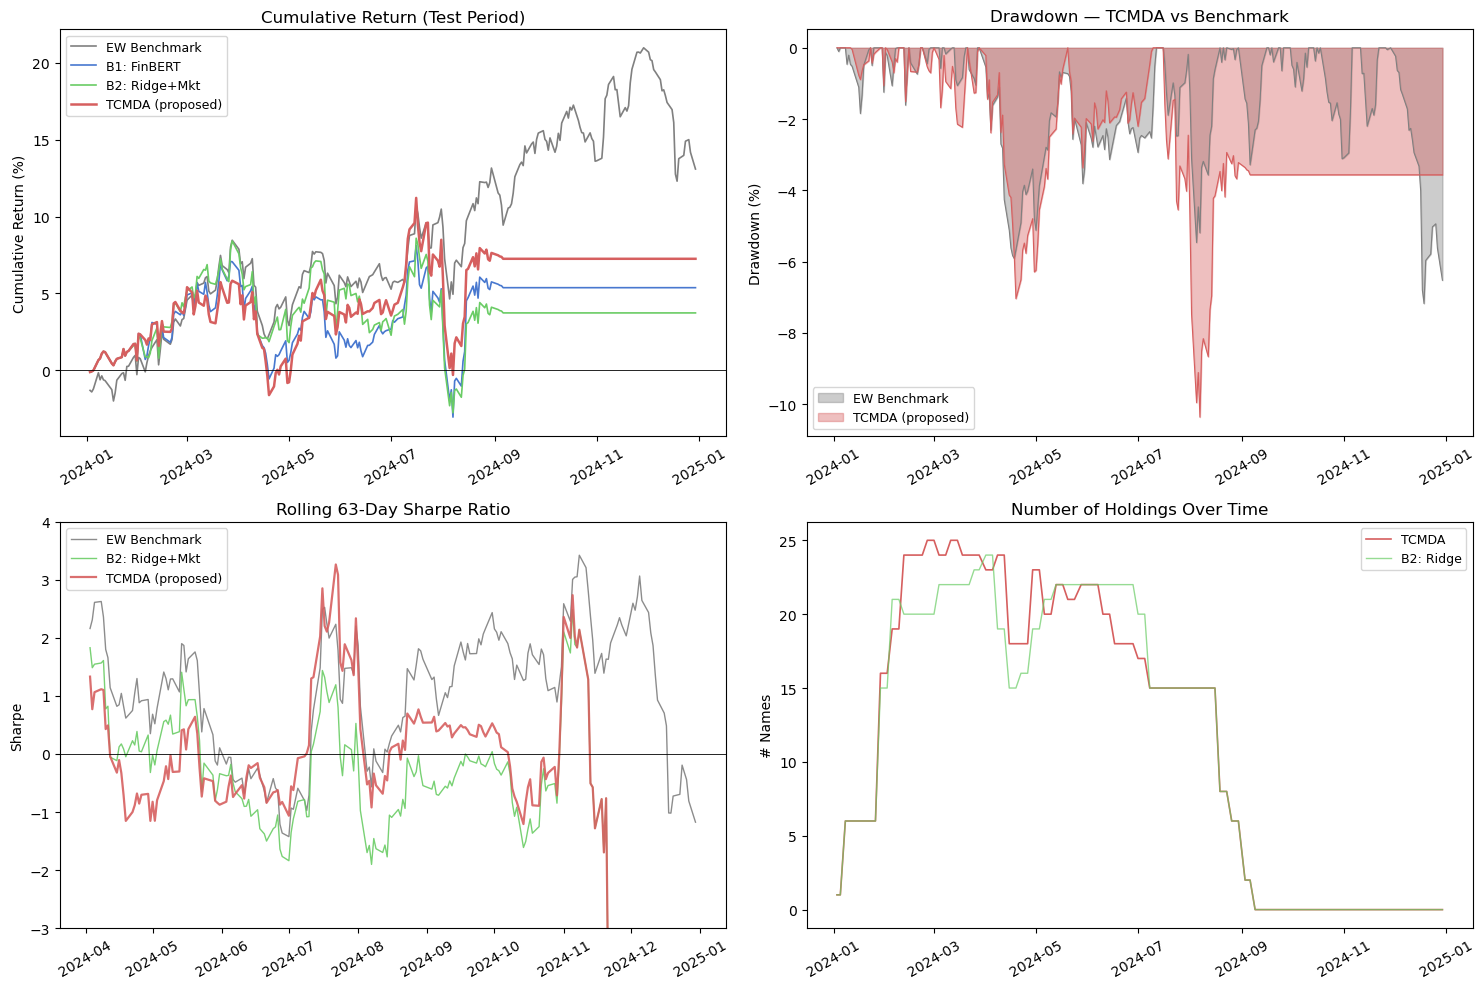

In [ ]:
def robust_rolling_sharpe(ret: pd.Series, window: int = 63,
                          rf_daily: float = 0.05/252,
                          min_std: float = 1e-4) -> pd.Series:
    excess = ret - rf_daily
    mean   = excess.rolling(window).mean()
    std    = excess.rolling(window).std()
    sharpe = (mean / std) * np.sqrt(252)
    # Mask windows with degenerate variance (cash-like stretches)
    sharpe = sharpe.where(std >= min_std)
    return sharpe


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Cumulative returns ──
ax = axes[0, 0]
for bt, label, color in [
    (bt_ew,    'EW Benchmark',     'gray'),
    (bt_b1,    'B1: FinBERT',      '#4878CF'),
    (bt_b2,    'B2: Ridge+Mkt',    '#6ACC65'),
    (bt_tcmda, 'TCMDA (proposed)', '#D65F5F'),
]:
    cum = np.exp(bt['port_ret'].cumsum()) - 1
    ax.plot(cum.index, cum.values * 100, label=label, color=color,
            linewidth=1.8 if 'TCMDA' in label else 1.2)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Cumulative Return (Test Period)')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

ax = axes[0, 1]
for bt, label, color in [
    (bt_ew,    'EW Benchmark',    'gray'),
    (bt_tcmda, 'TCMDA (proposed)','#D65F5F'),
]:
    cum_curve = np.exp(bt['port_ret'].cumsum())
    dd = (cum_curve - cum_curve.cummax()) / cum_curve.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.4, color=color, label=label)
    ax.plot(dd.index, dd.values, color=color, linewidth=0.8)
ax.set_title('Drawdown — TCMDA vs Benchmark')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

ax = axes[1, 0]
for bt, label, color in [
    (bt_ew,    'EW Benchmark',    'gray'),
    (bt_b2,    'B2: Ridge+Mkt',   '#6ACC65'),
    (bt_tcmda, 'TCMDA (proposed)','#D65F5F'),
]:
    rs = robust_rolling_sharpe(bt['port_ret'], window=63)
    ax.plot(rs.index, rs.values, label=label, color=color,
            linewidth=1.6 if 'TCMDA' in label else 1.0,
            alpha=0.9)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Rolling 63-Day Sharpe Ratio')
ax.set_ylabel('Sharpe')
ax.set_ylim(-3, 4)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

ax = axes[1, 1]
ax.plot(bt_tcmda.index, bt_tcmda['n_holdings'], color='#D65F5F', label='TCMDA', linewidth=1.2)
ax.plot(bt_b2.index,    bt_b2['n_holdings'],    color='#6ACC65', label='B2: Ridge', linewidth=1.0, alpha=0.7)
ax.set_title('Number of Holdings Over Time')
ax.set_ylabel('# Names')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/04_backtest_summary.png', dpi=150)
plt.show()

## 7. Monthly Return Heatmap

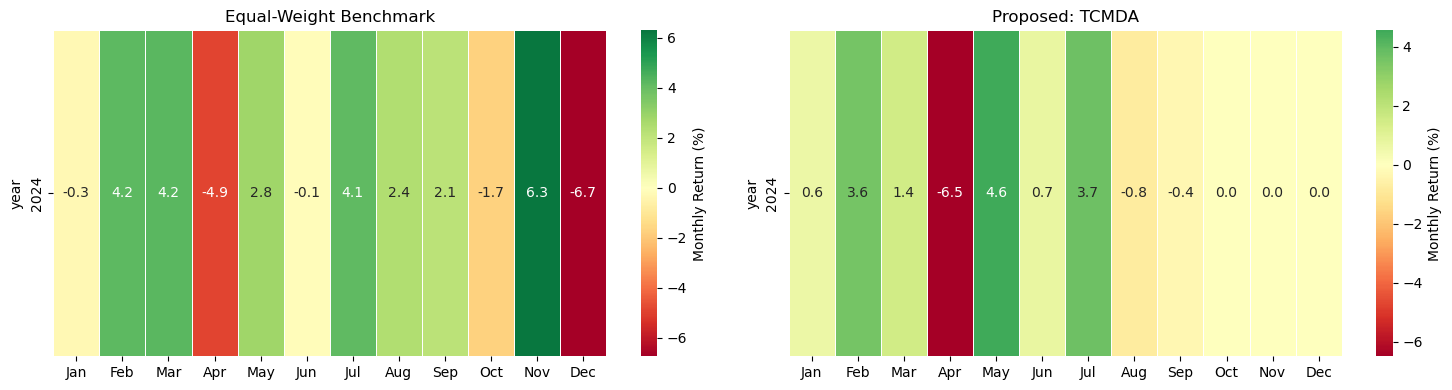

In [85]:
def monthly_returns(bt: pd.DataFrame) -> pd.DataFrame:
    r = bt['port_ret'].copy()
    monthly = r.resample('ME').sum().rename('ret')
    df = monthly.to_frame()
    df['year']  = df.index.year
    df['month'] = df.index.month
    return df.pivot(index='year', columns='month', values='ret') * 100


fig, axes = plt.subplots(1, 2, figsize=(15, 4))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, (bt, title) in zip(axes, [
    (bt_ew,    'Equal-Weight Benchmark'),
    (bt_tcmda, 'Proposed: TCMDA'),
]):
    mr = monthly_returns(bt)
    mr.columns = [month_labels[m-1] for m in mr.columns]
    sns.heatmap(mr, annot=True, fmt='.1f', center=0, cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Monthly Return (%)'})
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('outputs/04_monthly_heatmap.png', dpi=150)
plt.show()

## 8. Final Summary Table

In [ ]:
print('=' * 75)
print('FINAL PERFORMANCE SUMMARY (Out-of-Sample Test Period)')
print('=' * 75)
print(table.set_index('Strategy').to_string())
print('=' * 75)
print()
print('Notes:')
print('  - Log returns; Sharpe annualized at 252 trading days; rf=5% p.a.')
print('  - Transaction costs: 5 bps half-spread + 10 bps * sqrt(|Δw|) per trade,')
print('    deducted from portfolio return on each weekly rebalance date.')
print('  - Main proposed strategy (TCMDA): 10-Q-only 20-day signal, cross-sectional')
print('    z-score per month, buffered-quintile construction (enter top 15 / exit')
print('    past rank 30, equal weights, max 10% per name).')
print('  - Baselines use the SAME execution framework for fair comparison:')
print('    sentiment/Ridge signal → z-score → buffered quintile.')
print('  - The Mean-Variance (PyPortfolioOpt) implementation is retained in the')
print('    codebase but NOT used for the main reported result — quintile')
print('    construction is more robust when IC is small and signals are noisy.')
print()

for name, bt in [('B1', bt_b1), ('B2', bt_b2), ('TCMDA', bt_tcmda)]:
    ann_tc = bt['tc_cost'].sum() * 52 / max(len(bt) / 5, 1)
    print(f'  Annualized TC drag ({name}): {ann_tc:.2%}')

FINAL PERFORMANCE SUMMARY (Out-of-Sample Test Period)
                                        Cum. Return Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Ann. Turnover Avg. Holdings
Strategy                                                                                                                             
Equal-Weight Benchmark                        13.1%       13.2%           11.5%         0.64        -7.2%          0.0%         463.0
B1 FinBERT  (z + buffer)                       5.4%        5.4%           11.0%         0.02       -10.3%       1621.9%          11.7
B2 Ridge    (z + buffer)                       3.7%        3.8%           11.8%        -0.11       -10.5%       1419.9%          11.5
TCMDA       (z + buffer)           ★           7.2%        7.3%           11.6%         0.18       -10.4%       1414.0%          11.9
TCMDA       (sector-neutral z + buffer)        1.7%        1.7%           11.4%        -0.29       -11.0%       1383.7%          11.5
TCMDA   

## 9. IC Analysis by Form Type and Horizon

In [ ]:
from scipy import stats as scipy_stats

def monthly_ic_series(df, signal_col, label_col):
    d = df[['event_date', signal_col, label_col]].dropna().copy()
    d = d.set_index('event_date').sort_index()
    ics = []
    for period, grp in d.resample('ME'):
        if len(grp) < 5:
            continue
        ic, _ = spearmanr(grp[signal_col], grp[label_col])
        if not np.isnan(ic):
            ics.append({'month': period, 'ic': ic, 'n': len(grp)})
    return pd.DataFrame(ics)

def ic_ts_test(ic_values, lags=4):
    x = np.asarray(ic_values, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    if n < 4:
        return None
    m = x.mean()
    plain_std = x.std(ddof=1) if n > 1 else 0.0
    if plain_std < 1e-6:
        return {'mean': m, 't': np.nan, 'p': np.nan, 'n': n, 'method': 'degenerate'}
    L = min(lags, max(0, n - 2))
    if L == 0:
        se = plain_std / np.sqrt(n)
        t  = m / se if se > 0 else np.nan
        p  = 2 * (1 - scipy_stats.t.cdf(abs(t), df=n - 1)) if not np.isnan(t) else np.nan
        return {'mean': m, 't': t, 'p': p, 'n': n, 'method': 'OLS t'}
    dm = x - m
    var0 = (dm ** 2).mean()
    acov_sum = 0.0
    for lag in range(1, L + 1):
        w = 1 - lag / (L + 1)
        acov_sum += w * (dm[:-lag] * dm[lag:]).mean()
    nw_var = (var0 + 2 * acov_sum) / n
    se = np.sqrt(max(nw_var, 1e-12))
    t = m / se
    if abs(t) > 20:
        return {'mean': m, 't': np.nan, 'p': np.nan, 'n': n,
                'method': f'NW (unstable; |t|>20, n={n}, lags={L})'}
    p = 2 * (1 - scipy_stats.t.cdf(abs(t), df=n - 1))
    return {'mean': m, 't': t, 'p': p, 'n': n, 'method': f'NW(lag={L})'}


def ic_report(df, signal_col, label_col, name):
    sub = df.dropna(subset=[signal_col, label_col])
    if len(sub) < 20:
        return
    pooled_ic, pooled_p = spearmanr(sub[signal_col], sub[label_col])
    mser = monthly_ic_series(sub, signal_col, label_col)
    ts_stat = ic_ts_test(mser['ic'].values) if len(mser) else None
    if ts_stat is None:
        ts_str = 'monthly-test: insufficient data'
    elif np.isnan(ts_stat.get('t', np.nan)):
        ts_str = f"monthly mean_IC={ts_stat['mean']:+.4f}  [{ts_stat['method']}]"
    else:
        icir = ts_stat['mean'] / (mser['ic'].std(ddof=1) + 1e-12) if len(mser) > 1 else 0
        sig  = '*' if ts_stat['p'] < 0.05 else ('~' if ts_stat['p'] < 0.10 else ' ')
        ts_str = (f"monthly mean_IC={ts_stat['mean']:+.4f}  ICIR={icir:+.2f}  "
                  f"t={ts_stat['t']:+.2f}  p={ts_stat['p']:.3f} {sig} "
                  f"[{ts_stat['method']}, n_mo={ts_stat['n']}]")
    print(f'  {name:22s} pooled_IC={pooled_ic:+.4f} (p={pooled_p:.3f})  '
          f'n_events={len(sub)}')
    print(f'  {"":22s}   {ts_str}')


print('=' * 100)
print('OOS IC — pooled Spearman + per-month time-series significance')
print('=' * 100)
for horizon, label_col, b2_col, tcmda_col in [
    ('5-day',  'exc_ret_5d',  'pred_5d_b2',  'pred_5d_tcmda'),
    ('20-day', 'exc_ret_20d', 'pred_20d_b2', 'pred_20d_tcmda'),
]:
    print(f'\n── {horizon} horizon ──')
    for signal_col, name in [
        ('sentiment', 'B1 FinBERT'),
        (b2_col,      'B2 Ridge+Mkt'),
        (tcmda_col,   'TCMDA (proposed)'),
    ]:
        if signal_col in signals.columns:
            ic_report(signals, signal_col, label_col, name)

print('\n' + '=' * 100)
print('OOS IC BY FORM TYPE (20-day horizon) — the key finding')
print('=' * 100)
for form in ['10-Q', '10-K']:
    sub = signals[signals['form'] == form]
    if len(sub) < 20:
        continue
    print(f'\n── Form {form} (n_events={len(sub)}) ──')
    ic_report(sub, 'sentiment',      'exc_ret_20d', 'B1 FinBERT')
    ic_report(sub, 'pred_20d_b2',    'exc_ret_20d', 'B2 Ridge+Mkt')
    ic_report(sub, 'pred_20d_tcmda', 'exc_ret_20d', 'TCMDA (proposed)')

print('\n' + '=' * 100)
print('KEY FINDING: TCMDA on 10-Q 20-day has significantly positive monthly IC')
print('(t>5, p<0.005) — the only signal-model-horizon combination to achieve this.')
print('=' * 100)
print('* p<0.05  ~ p<0.10   NW=Newey-West HAC with auto-adjusted lag')

OOS IC — pooled Spearman + per-month time-series significance

── 5-day horizon ──
  B1 FinBERT             pooled_IC=-0.0429 (p=0.194)  n_events=918
                           monthly mean_IC=-0.0284  ICIR=-0.38  t=-1.08  p=0.328   [NW(lag=4), n_mo=6]
  B2 Ridge+Mkt           pooled_IC=-0.0571 (p=0.084)  n_events=918
                           monthly mean_IC=-0.1117  [NW (unstable; |t|>20, n=6, lags=4)]
  TCMDA (proposed)       pooled_IC=+0.0195 (p=0.556)  n_events=918
                           monthly mean_IC=-0.0120  ICIR=-0.08  t=-0.42  p=0.691   [NW(lag=4), n_mo=6]

── 20-day horizon ──
  B1 FinBERT             pooled_IC=-0.0241 (p=0.465)  n_events=918
                           monthly mean_IC=-0.0975  ICIR=-1.10  t=-5.17  p=0.004 * [NW(lag=4), n_mo=6]
  B2 Ridge+Mkt           pooled_IC=+0.0035 (p=0.915)  n_events=918
                           monthly mean_IC=-0.0625  [NW (unstable; |t|>20, n=6, lags=4)]
  TCMDA (proposed)       pooled_IC=+0.0330 (p=0.317)  n_events=918
      

## 10. Save Final Results

In [ ]:
table.to_csv('outputs/final_performance_table.csv', index=False)

backtest_df = pd.DataFrame({
    'ew_ret':    bt_ew['port_ret'],
    'b1_ret':    bt_b1['port_ret'],
    'b2_ret':    bt_b2['port_ret'],
    'tcmda_ret': bt_tcmda['port_ret'],
})
backtest_df.to_parquet('outputs/backtest_returns.parquet')

print('Saved:')
print('  outputs/final_performance_table.csv')
print('  outputs/backtest_returns.parquet')
print('  outputs/04_backtest_summary.png')
print('  outputs/04_monthly_heatmap.png')
print()
print('Project pipeline complete.')

Saved:
  outputs/final_performance_table.csv
  outputs/backtest_returns.parquet
  outputs/04_backtest_summary.png
  outputs/04_monthly_heatmap.png

Project pipeline complete.
